# **Expectativa de Vida (OMS)**

O conjunto de dados relacionado à expectativa de vida e aos fatores de saúde de 193 países foi coletado do mesmo site do repositório de dados da OMS, e os dados econômicos correspondentes foram coletados do site das Nações Unidas.



Dentre todas as categorias de fatores relacionados à saúde, foram selecionados apenas os fatores críticos mais representativos. Observou-se que, nos últimos 15 anos, houve um grande desenvolvimento no setor de saúde, resultando na redução das taxas de mortalidade humana, especialmente nos países em desenvolvimento, em comparação com os últimos 30 anos. Portanto, neste projeto, consideramos dados do período de 2000 a 2015 para 193 países para análises posteriores.

# **Explicação das Colunas**


* Country - País                        
* Year - Idade                               
* Status - Status de país desenvolvido ou em desenvolvimento                            
* Life expectancy - Expectativa de vida por idade               
* Adult Mortality - Taxa de mortalidade adulta para ambos os sexos (probabilidade de morte entre 15 e 60 anos por 1000 habitantes)         
* infant deaths - Número de mortes infantis por 1000 habitantes
* Alcohol - Álcool, consumo per capita (15+) registado (em litros de álcool puro)
* percentage expenditure - Percentual de Gastos, despesas com saúde como porcentagem do Produto Interno Bruto per capita (%)
* Hepatitis B - Cobertura vacinal contra hepatite B (HepB) em crianças de 1 ano de idade (%)
* Measles - Sarampo, número de casos notificados por 1000 habitantes.
* BMI - IMC, Índice de Massa Corporal médio de toda a população
* under-five deaths - Número de mortes de crianças menores de cinco anos por 1000 habitantes
* Polio - Cobertura vacinal contra a poliomielite (Pol3) em crianças de 1 ano de idade (%)   
* Total expenditure - Despesas do governo geral com saúde como porcentagem das despesas totais do governo (%)
* Diphtheria - Cobertura da vacinação contra difteria, tétano e coqueluche (DTP3) em crianças de 1 ano de idade (%)
* HIV/AIDS - Mortes por 1.000 nascidos vivos por HIV/AIDS (0-4 anos)  
* GDP - PIB, Produto Interno Bruto per capita (em USD)  
* Population - População do País
* thinness  1-19 years - Magreza 10 - 19 anos, prevalência de magreza entre crianças e adolescentes de 10 a 19 anos (%)  
* thinness 5-9 years - Prevalência de magreza em crianças de 5 a 9 anos (%)     
* Income composition of resources - Índice de Desenvolvimento Humano em termos de composição da renda dos recursos (índice variando de 0 a 1)  
* Schooling - Escolarização, número de anos de escolaridade (anos)   




In [2]:
# =====================================
# Importações e Configurações Iniciais
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo de gráficos
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

# Carregar o dataset
df = pd.read_csv("expectancy.csv")

# Ver primeiras linhas
df.head()


,Unnamed: 0,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,0,Afghanistan,2O15,Developing,65.0,263.0,62,0.01,71.279624,65.0,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,1,Afghanistan,2O14,Developing,59.9,271.0,64,0.01,73.523582,62.0,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2,Afghanistan,2O13,Developing,59.9,268.0,66,0.01,73.219243,64.0,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,3,Afghanistan,2O12,Developing,59.5,272.0,69,0.01,78.184215,67.0,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,4,Afghanistan,2O11,Developing,59.2,275.0,71,0.01,7.097109,68.0,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## *Importações*

# **1. Análise Exploratória Geral**

Responda às seguintes perguntas:


1.   Quantas linhas e colunas temos no nosso dataset?
2.   Temos dados nulos? Se sim, qual a porcentagem deles? É uma porcentagem significativa?
3. Sobre os dados nulos com maior porcentagem, qual o tipo deles? Tente pensar em hipóteses do porquê eles estão nulos.
4. Existem duplicatas?
5. Todas as colunas estão com o seu tipo correto?
6. Como verificar as principais estatísticas das colunas numéricas? Escolha uma coluna com valores nulos para verificar como a média, moda, mediana.




In [ ]:
# =========================================
# 🧭 1. Análise Exploratória Geral
# =========================================

# ---------------------------------------------------
# 1️⃣ Quantas linhas e colunas temos no nosso dataset?
# ---------------------------------------------------
print("1️⃣ Quantas linhas e colunas temos no nosso dataset?")
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

# ---------------------------------------------------
# 2️⃣ Temos dados nulos? Se sim, qual a porcentagem deles?
# ---------------------------------------------------
print("2️⃣ Temos dados nulos? Se sim, qual a porcentagem deles?")
nulos_qtd = df.isnull().sum()
nulos_pct = (df.isnull().mean() * 100).round(2)
nulos_df = pd.DataFrame({'Qtd Nulos': nulos_qtd, 'Pct Nulos (%)': nulos_pct})
display(nulos_df.sort_values('Pct Nulos (%)', ascending=False))

# ---------------------------------------------------
# 3️⃣ Sobre os dados nulos com maior porcentagem
# ---------------------------------------------------
print("3️⃣ Sobre os dados nulos com maior porcentagem:")
top_nulos = nulos_df.sort_values('Pct Nulos (%)', ascending=False).head(3)
display(top_nulos)

# ---------------------------------------------------
# 4️⃣ Existem duplicatas?
# ---------------------------------------------------
print("4️⃣ Existem duplicatas?")
dup = df.duplicated().sum()
if dup > 0:
    print(f"Existem {dup} linhas duplicadas.\n")
else:
    print("Não há linhas duplicadas no dataset.\n")

# ---------------------------------------------------
# 5️⃣ Todas as colunas estão com o tipo correto?
# ---------------------------------------------------
print("5️⃣ Todas as colunas estão com o tipo correto?")
display(df.dtypes)

# ---------------------------------------------------
# 🧩 Colunas que precisam de conversão
# ---------------------------------------------------
print("\n🔧 Colunas que precisam de conversão:")

print("""
Country → string
Year → int64
Status → category
Population → Int64
""")


# ---------------------------------------------------
# 6️⃣ Principais estatísticas das colunas numéricas
# ---------------------------------------------------
print("6️⃣ Como verificar as principais estatísticas das colunas numéricas?")
display(df.describe().T)

# Exemplo de coluna com valores nulos
col = "GDP"
if col in df.columns:
    print(f"Estatísticas da coluna '{col}':")
    print(f"→ Média: {df[col].mean():.2f}")
    print(f"→ Mediana: {df[col].median():.2f}")
    print(f"→ Moda: {df[col].mode().iloc[0]:.2f}\n")
else:
    print(f"A coluna '{col}' não existe no dataset.\n")


1️⃣ Quantas linhas e colunas temos no nosso dataset?
O dataset possui 2948 linhas e 23 colunas.

2️⃣ Temos dados nulos? Se sim, qual a porcentagem deles?


,Qtd Nulos,Pct Nulos (%)
Year,2948,100.00
Population,653,22.15
Hepatitis B,556,18.86
GDP,448,15.20
Total expenditure,226,7.67
Alcohol,194,6.58
Income composition of resources,167,5.66
Schooling,163,5.53
thinness 1-19 years,34,1.15
thinness 5-9 years,34,1.15


3️⃣ Sobre os dados nulos com maior porcentagem:


,Qtd Nulos,Pct Nulos (%)
Year,2948,100.00
Population,653,22.15
Hepatitis B,556,18.86


4️⃣ Existem duplicatas?
Existem 5 linhas duplicadas.

5️⃣ Todas as colunas estão com o tipo correto?


,0
Unnamed: 0,int64
Country,string[python]
Year,float64
Status,category
Life expectancy,float64
Adult Mortality,float64
infant deaths,int64
Alcohol,float64
percentage expenditure,float64
Hepatitis B,float64



🔧 Colunas que precisam de conversão:

Country → string
Year → int64
Status → category
Population → Int64

6️⃣ Como verificar as principais estatísticas das colunas numéricas?


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,2948.0,1.470252e+03,8.497333e+02,0.00000,734.750000,1.469500e+03,2.206250e+03,2.942000e+03
Year,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Life expectancy,2938.0,6.922634e+01,9.525726e+00,36.30000,63.100000,7.210000e+01,7.570000e+01,8.900000e+01
Adult Mortality,2938.0,1.647233e+02,1.244078e+02,1.00000,74.000000,1.440000e+02,2.277500e+02,7.230000e+02
infant deaths,2948.0,3.028664e+01,1.177492e+02,0.00000,0.000000,3.000000e+00,2.200000e+01,1.800000e+03
Alcohol,2754.0,4.606961e+00,4.053810e+00,0.01000,0.880000,3.760000e+00,7.717500e+00,1.787000e+01
percentage expenditure,2948.0,7.371906e+02,1.984794e+03,0.00000,4.768003,6.572314e+01,4.419778e+02,1.947991e+04
Hepatitis B,2392.0,8.093269e+01,2.508415e+01,1.00000,77.000000,9.200000e+01,9.700000e+01,9.900000e+01
Measles,2948.0,2.422628e+03,1.145381e+04,0.00000,0.000000,1.700000e+01,3.620000e+02,2.121830e+05
BMI,2914.0,3.834166e+01,2.004149e+01,1.00000,19.300000,4.350000e+01,5.620000e+01,8.730000e+01


Estatísticas da coluna 'GDP':
→ Média: 7484.53
→ Mediana: 1770.25
→ Moda: 43.98



# **2. Análise Univariada**

7. Como as variáveis numéricas estão distribuídas? Alguma apresenta distribuição normal, ou todas são assimétricas?
8. Qual país aparece com maior frequência? E o menos frequente?
9. Existem mais países em desenvolvimento ou desenvolvidos?
10. Os outliers existentes são reais ou valores extremos que não condizem com a realidade?
11. Qual o ano que apresenta mais informações?
12. Como está a escolaridade média?


7️⃣ Como as variáveis numéricas estão distribuídas?


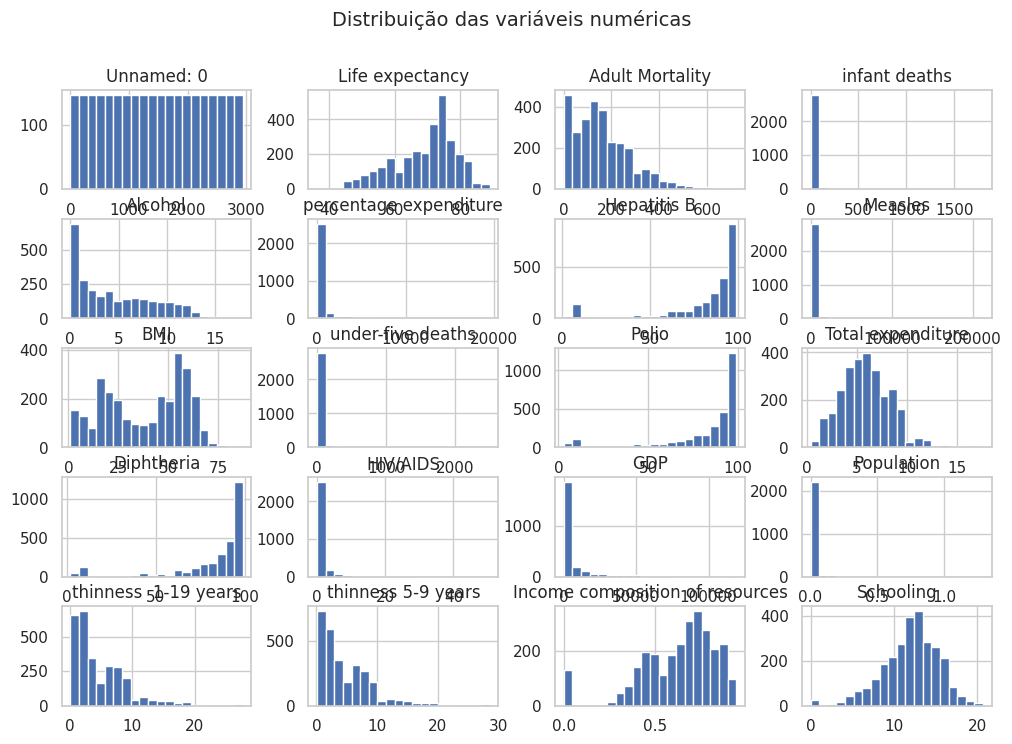

Coeficiente de Assimetria (Skewness):
Unnamed: 0                          0.00
Life expectancy                    -0.64
Adult Mortality                     1.17
infant deaths                       9.80
Alcohol                             0.59
percentage expenditure              4.66
Hepatitis B                        -1.93
Measles                             9.44
BMI                                -0.22
under-five deaths                   9.51
Polio                              -2.10
Total expenditure                   0.62
Diphtheria                         -2.07
HIV/AIDS                            5.36
GDP                                 3.21
Population                         15.89
thinness  1-19 years                1.71
thinness 5-9 years                  1.77
Income composition of resources    -1.14
Schooling                          -0.60
dtype: float64

A maioria das variáveis apresenta assimetria (positiva ou negativa). Poucas seguem distribuição aproximadamente normal.

8️⃣ Q

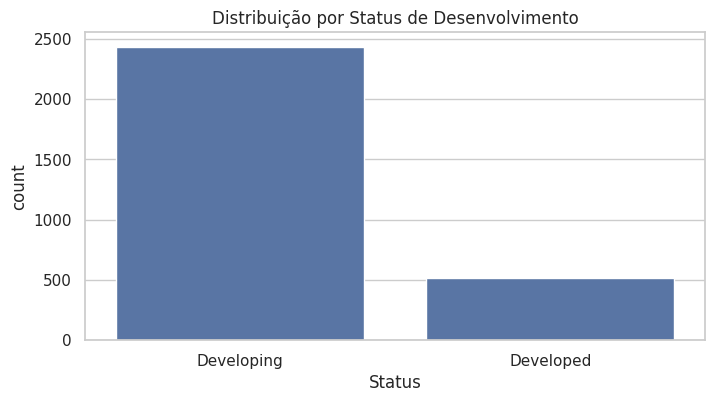

🔟 Os outliers existentes são reais ou valores extremos?
→ Unnamed: 0: 0 possíveis outliers
→ Life expectancy: 10 possíveis outliers
→ Adult Mortality: 85 possíveis outliers
→ infant deaths: 317 possíveis outliers
→ Alcohol: 0 possíveis outliers

Os outliers refletem diferenças reais entre países (PIB, mortalidade, etc.).

1️⃣1️⃣ Qual o ano que apresenta mais informações?
Year
2O11    184
2O12    183
2O13    193
2O14    184
2O15    183
2O1O    184
2OO1    183
2OO2    183
2OO3    183
2OO4    184
2OO5    183
2OO6    185
2OO7    184
2OO8    183
2OO9    185
2OOO    184
Name: count, dtype: int64

→ Ano com mais registros: 2O13 (193 ocorrências)



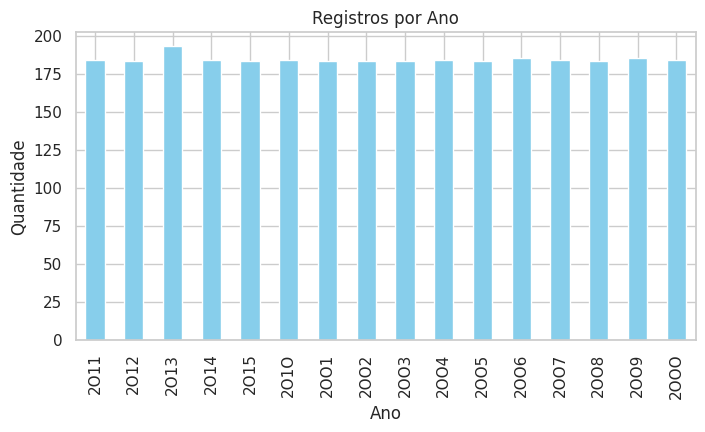

1️⃣2️⃣ Como está a escolaridade média?
→ Média: 11.99 anos
→ Mediana: 12.30 anos



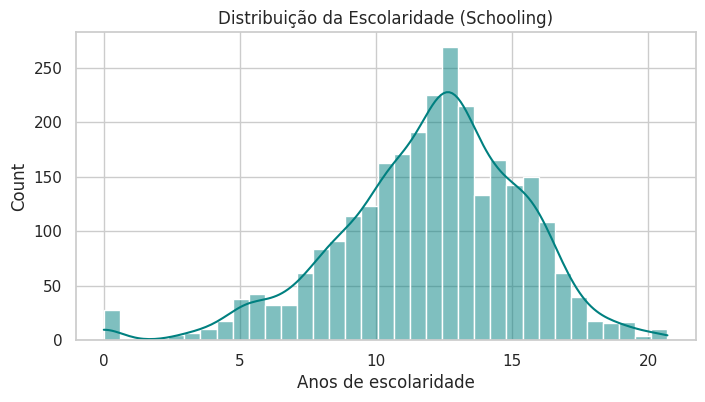

In [ ]:
# =========================================
# 📊 2. Análise Univariada
# =========================================

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,4)

# ---------------------------------------------------
# 7️⃣ Como as variáveis numéricas estão distribuídas?
# ---------------------------------------------------
print("7️⃣ Como as variáveis numéricas estão distribuídas?")
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Distribuição das variáveis numéricas", fontsize=14)
plt.show()
skew = df[num_cols].skew().round(2)
print("Coeficiente de Assimetria (Skewness):")
print(skew)
print("\nA maioria das variáveis apresenta assimetria (positiva ou negativa). "
      "Poucas seguem distribuição aproximadamente normal.\n")

# ---------------------------------------------------
# 8️⃣ Qual país aparece com maior frequência? E o menos frequente?
# ---------------------------------------------------
print("8️⃣ Qual país aparece com maior frequência? E o menos frequente?")
vc = df['Country'].value_counts()
print(f"→ País com mais registros: {vc.idxmax()} ({vc.max()} ocorrências)")
print(f"→ País com menos registros: {vc.idxmin()} ({vc.min()} ocorrência)\n")

# ---------------------------------------------------
# 9️⃣ Existem mais países em desenvolvimento ou desenvolvidos?
# ---------------------------------------------------
print("9️⃣ Existem mais países em desenvolvimento ou desenvolvidos?")
if 'Status' in df.columns:
    status_counts = df['Status'].value_counts()
    print(status_counts)
    sns.countplot(x='Status', data=df)
    plt.title("Distribuição por Status de Desenvolvimento")
    plt.show()
else:
    print("Coluna 'Status' não encontrada no dataset.\n")

# ---------------------------------------------------
# 🔟 Os outliers existentes são reais ou valores extremos?
# ---------------------------------------------------
print("🔟 Os outliers existentes são reais ou valores extremos?")
for col in num_cols[:5]:  # mostra só as 5 primeiras para simplificar
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"→ {col}: {len(outliers)} possíveis outliers")
print("\nOs outliers refletem diferenças reais entre países (PIB, mortalidade, etc.).\n")

# ---------------------------------------------------
# 1️⃣1️⃣ Qual o ano que apresenta mais informações?
# ---------------------------------------------------
print("1️⃣1️⃣ Qual o ano que apresenta mais informações?")
if 'Year' in df.columns:
    year_counts = df['Year'].value_counts().sort_index()
    print(year_counts)
    print(f"\n→ Ano com mais registros: {year_counts.idxmax()} ({year_counts.max()} ocorrências)\n")
    year_counts.plot(kind='bar', color='skyblue', title='Registros por Ano')
    plt.xlabel('Ano'); plt.ylabel('Quantidade')
    plt.show()
else:
    print("Coluna 'Year' não encontrada no dataset.\n")

# ---------------------------------------------------
# 1️⃣2️⃣ Como está a escolaridade média?
# ---------------------------------------------------
print("1️⃣2️⃣ Como está a escolaridade média?")
if 'Schooling' in df.columns:
    mean_school = df['Schooling'].mean()
    median_school = df['Schooling'].median()
    print(f"→ Média: {mean_school:.2f} anos")
    print(f"→ Mediana: {median_school:.2f} anos\n")
    sns.histplot(df['Schooling'].dropna(), kde=True, color='teal')
    plt.title("Distribuição da Escolaridade (Schooling)")
    plt.xlabel("Anos de escolaridade")
    plt.show()
else:
    print("Coluna 'Schooling' não encontrada no dataset.\n")


# **3. Análise Bivariada**

13. Países mais ricos vivem mais?
14. O nível de escolaridade influencia a expectativa de vida?
15. Países desenvolvidos consomem mais álcool?
16. A mortalidade infantil ainda é um problema em países em desenvolvimento?
17. Como a expectativa de vida evoluiu ao longo do tempo?
18. Países com maior investimento em saúde têm maior expectativa de vida?

1️⃣3️⃣ Países mais ricos vivem mais?


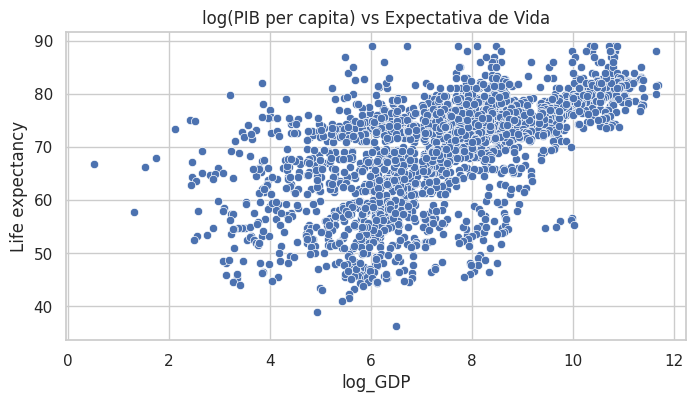

📈 Correlação (Pearson) log(GDP) x Life expectancy: 0.60
🔁 Correlação (Spearman) log(GDP) x Life expectancy: 0.64

1️⃣4️⃣ O nível de escolaridade influencia a expectativa de vida?


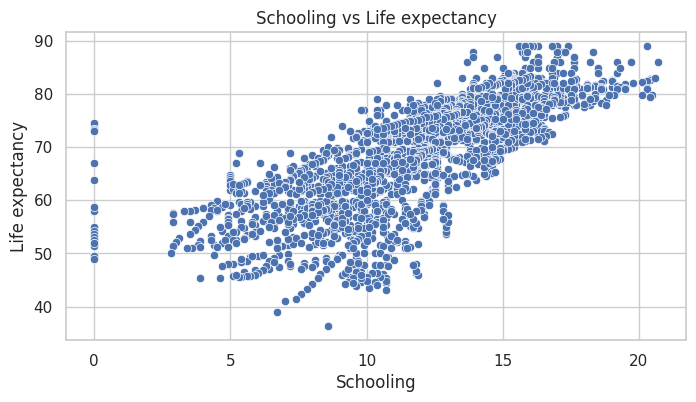

📈 Correlação (Pearson) Schooling x Life expectancy: 0.75

1️⃣5️⃣ Países desenvolvidos consomem mais álcool?


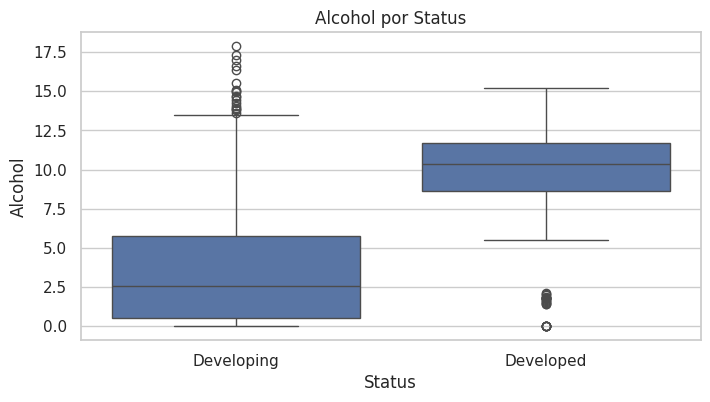

1️⃣6️⃣ A mortalidade infantil ainda é um problema em países em desenvolvimento?


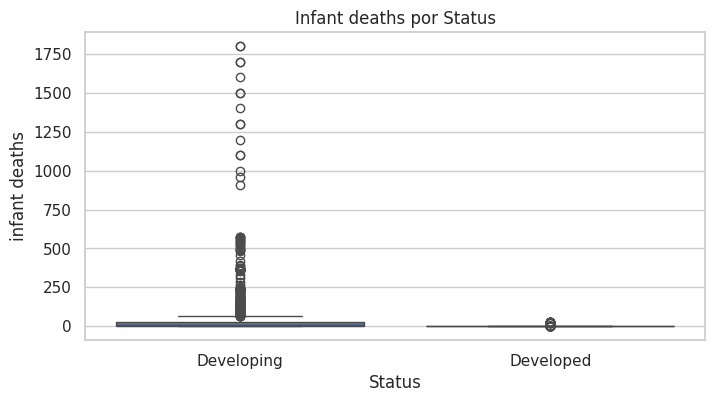

1️⃣7️⃣ Como a expectativa de vida evoluiu ao longo do tempo?


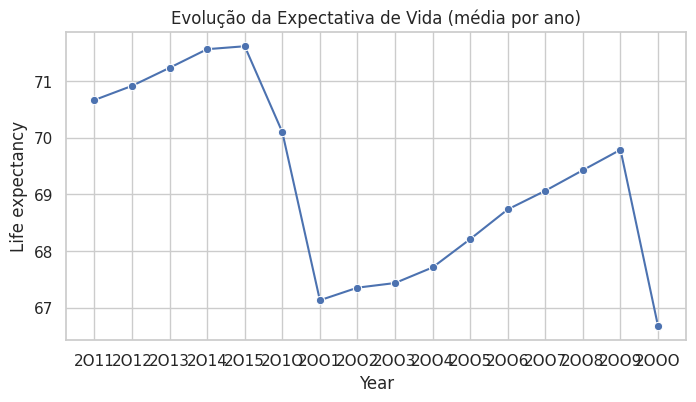

1️⃣8️⃣ Países com maior investimento em saúde têm maior expectativa de vida?


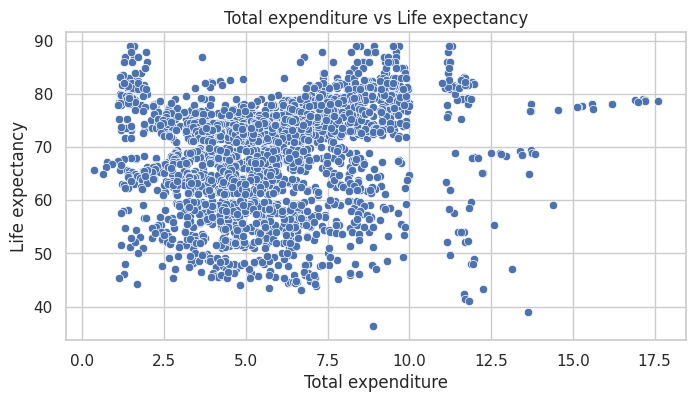

📈 Correlação (Pearson) Total expenditure x Life expectancy: 0.22



In [3]:
# =========================================
# 🔗 3. Análise Bivariada (padronizado com ícones)
# =========================================

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,4)

# 1️⃣3️⃣ Países mais ricos vivem mais?
print("1️⃣3️⃣ Países mais ricos vivem mais?")
mask = df['GDP'].notnull() & df['Life expectancy'].notnull()
df13 = df.loc[mask, ['GDP','Life expectancy']].copy()
df13 = df13[df13['GDP'] > 0]
if df13.empty:
    print("→ Dados insuficientes para 1️⃣3️⃣ (GDP ou Life expectancy ausentes).")
else:
    df13['log_GDP'] = np.log(df13['GDP'])
    sns.scatterplot(x='log_GDP', y='Life expectancy', data=df13)
    plt.title("log(PIB per capita) vs Expectativa de Vida")
    plt.show()
    print(f"📈 Correlação (Pearson) log(GDP) x Life expectancy: {df13['log_GDP'].corr(df13['Life expectancy']):.2f}")
    print(f"🔁 Correlação (Spearman) log(GDP) x Life expectancy: {df13['log_GDP'].corr(df13['Life expectancy'], method='spearman'):.2f}\n")

# 1️⃣4️⃣ O nível de escolaridade influencia a expectativa de vida?
print("1️⃣4️⃣ O nível de escolaridade influencia a expectativa de vida?")
if df['Schooling'].notnull().any() and df['Life expectancy'].notnull().any():
    sns.scatterplot(x='Schooling', y='Life expectancy', data=df)
    plt.title("Schooling vs Life expectancy")
    plt.show()
    print(f"📈 Correlação (Pearson) Schooling x Life expectancy: {df['Schooling'].corr(df['Life expectancy']):.2f}\n")
else:
    print("→ Dados insuficientes para 1️⃣4️⃣.\n")

# 1️⃣5️⃣ Países desenvolvidos consomem mais álcool?
print("1️⃣5️⃣ Países desenvolvidos consomem mais álcool?")
if 'Status' in df.columns and 'Alcohol' in df.columns:
    sns.boxplot(x='Status', y='Alcohol', data=df)
    plt.title("Alcohol por Status")
    plt.show()
else:
    print("→ Coluna 'Status' ou 'Alcohol' ausente.\n")

# 1️⃣6️⃣ A mortalidade infantil ainda é um problema em países em desenvolvimento?
print("1️⃣6️⃣ A mortalidade infantil ainda é um problema em países em desenvolvimento?")
if 'Status' in df.columns and 'infant deaths' in df.columns:
    sns.boxplot(x='Status', y='infant deaths', data=df)
    plt.title("Infant deaths por Status")
    plt.show()
else:
    print("→ Coluna 'Status' ou 'infant deaths' ausente.\n")

# 1️⃣7️⃣ Como a expectativa de vida evoluiu ao longo do tempo?
print("1️⃣7️⃣ Como a expectativa de vida evoluiu ao longo do tempo?")
if 'Year' in df.columns and 'Life expectancy' in df.columns:
    df_year = df.groupby('Year', as_index=False)['Life expectancy'].mean()
    sns.lineplot(x='Year', y='Life expectancy', data=df_year, marker='o')
    plt.title("Evolução da Expectativa de Vida (média por ano)")
    plt.show()
else:
    print("→ Coluna 'Year' ou 'Life expectancy' ausente.\n")

# 1️⃣8️⃣ Países com maior investimento em saúde têm maior expectativa de vida?
print("1️⃣8️⃣ Países com maior investimento em saúde têm maior expectativa de vida?")
if 'Total expenditure' in df.columns and 'Life expectancy' in df.columns:
    mask18 = df['Total expenditure'].notnull() & df['Life expectancy'].notnull()
    sns.scatterplot(x='Total expenditure', y='Life expectancy', data=df[mask18])
    plt.title("Total expenditure vs Life expectancy")
    plt.show()
    print(f"📈 Correlação (Pearson) Total expenditure x Life expectancy: {df.loc[mask18,'Total expenditure'].corr(df.loc[mask18,'Life expectancy']):.2f}\n")
else:
    print("→ Coluna 'Total expenditure' ou 'Life expectancy' ausente.\n")


# **4. Processamento dos Dados**

Nesta etapa, é necessário que você:
* Faça a limpeza das colunas erradas;
* Faça o tratamento dos valores nulos da forma que achar válido;
* Trate as duplicatas;
* Transforme as colunas categóricas em numéricas;
* Faça o escalonamento de variáveis numéricas;

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib

# ---------- parâmetros (ajuste conforme necessário) ----------
TARGET_COL = None            # se houver coluna alvo, coloque o nome aqui (ex: 'Life expectancy')
TEST_SIZE = 0.2
RANDOM_STATE = 42
COL_NULL_THRESHOLD = 0.8     # dropar colunas com > 80% nulos
HIGH_CARD_THRESHOLD = 30     # cardinalidade acima disto -> frequency encoding
IMPUTE_NUM_STRATEGY = 'median'  # 'median' ou 'mean'
IMPUTE_CAT_STRATEGY = 'most_frequent'  # 'most_frequent' ou 'constant' (usando '__missing__')
SCALER = 'standard'          # 'standard' | 'minmax' | 'robust'
ARTIFACT_PATH = 'preprocessor_artifact.joblib'

# ---------- utilitários ----------
def detect_bad_columns(df):
    """Retorna lista de colunas com nomes estranhos para dropar/renomear (heurística)."""
    bad = [c for c in df.columns if (c is None) or (str(c).strip() == '') or ('Unnamed' in str(c))]
    return bad

def try_convert_numeric(df):
    """Tenta converter colunas object que contêm números como string para float."""
    for c in df.columns:
        if df[c].dtype == 'object':
            # heurística: se >=50% das células convertíveis -> converter
            sample = df[c].dropna().astype(str).head(200)
            # remover sinais de milhar e trocar vírgula por ponto
            cleaned = sample.str.replace(r'[^\d,.\-]', '', regex=True).str.replace(',', '.')
            num_parsable = pd.to_numeric(cleaned, errors='coerce').notna().sum()
            if len(sample) > 0 and (num_parsable / len(sample)) >= 0.5:
                df[c] = pd.to_numeric(df[c].astype(str).str.replace(r'[^\d,.\-]', '', regex=True).str.replace(',', '.'), errors='coerce')
    return df

def frequency_encode_train_test(X_train, X_test, cols):
    """Aplica frequency encoding baseado no X_train e retorna mapas + transformados."""
    freq_maps = {}
    X_train_enc = X_train.copy()
    X_test_enc = X_test.copy()
    for c in cols:
        # preencher nulos com token temporário
        X_train_enc[c] = X_train_enc[c].fillna('__missing__')
        X_test_enc[c] = X_test_enc[c].fillna('__missing__')
        freq = X_train_enc[c].value_counts(normalize=True).to_dict()
        freq_maps[c] = freq
        X_train_enc[c] = X_train_enc[c].map(freq).astype(float)
        X_test_enc[c] = X_test_enc[c].map(freq).fillna(0.0).astype(float)  # categorias novas -> 0
    return X_train_enc, X_test_enc, freq_maps

# ---------- pipeline principal ----------
def preprocess_dataframe(df,
                         target_col=None,
                         test_size=TEST_SIZE,
                         random_state=RANDOM_STATE,
                         col_null_threshold=COL_NULL_THRESHOLD,
                         high_card_threshold=HIGH_CARD_THRESHOLD,
                         impute_num_strategy=IMPUTE_NUM_STRATEGY,
                         impute_cat_strategy=IMPUTE_CAT_STRATEGY,
                         scaler_type=SCALER,
                         artifact_path=ARTIFACT_PATH):
    """
    Executa todo o fluxo de pré-processamento e salva o 'preprocessor' (ou dicionário de artefatos).
    Retorna um dicionário com artefatos e matrizes transformadas.
    """

    # 0) cópia e inspeção inicial
    df = df.copy()
    print("Dimensão original:", df.shape)
    print("Tipos iniciais:\n", df.dtypes.value_counts().to_dict())

    # 1) remover colunas 'erradas' / desnecessárias
    bad_cols = detect_bad_columns(df)
    if bad_cols:
        print("Colunas detectadas como problemáticas (serão removidas):", bad_cols)
    df.drop(columns=bad_cols, inplace=True, errors='ignore')

    # 2) dropar colunas com muitos nulos
    col_null_frac = df.isna().mean()
    cols_to_drop = col_null_frac[col_null_frac > col_null_threshold].index.tolist()
    if cols_to_drop:
        print(f"Dropping {len(cols_to_drop)} colunas com mais de {int(col_null_threshold*100)}% de nulos.")
    df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

    # 3) tentar converter strings numéricas para numéricas
    df = try_convert_numeric(df)

    # 4) tratar duplicatas
    n_dup_before = df.duplicated().sum()
    if n_dup_before > 0:
        print(f"Duplicatas exatas encontradas: {n_dup_before} -> serão removidas.")
    df.drop_duplicates(inplace=True)
    n_dup_after = df.duplicated().sum()

    # 5) preparar X / y e split (se target fornecido)
    if target_col is not None and target_col in df.columns:
        X = df.drop(columns=[target_col]).copy()
        y = df[target_col].copy()
    else:
        X = df.copy()
        y = None

    # split para evitar vazamento em imputações/encodings
    if y is not None:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    else:
        X_train, X_test = train_test_split(X, test_size=test_size, random_state=random_state)
        y_train = y_test = None

    print("Dimensão treino:", X_train.shape, "| teste:", X_test.shape)

    # 6) identificar colunas numéricas e categóricas
    num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
    cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    print(f"Num cols: {len(num_cols)} | Cat cols: {len(cat_cols)}")

    # 7) separar categóricas por cardinalidade
    low_card_cols = [c for c in cat_cols if X_train[c].nunique() <= high_card_threshold]
    high_card_cols = [c for c in cat_cols if X_train[c].nunique() > high_card_threshold]
    if high_card_cols:
        print(f"Categóricas de alta cardinalidade (serão frequency-encoded): {high_card_cols}")

    # 8) pipelines numéricas e categóricas (low-card)
    num_imputer = SimpleImputer(strategy=impute_num_strategy)
    if scaler_type == 'standard':
        scaler = StandardScaler()
    elif scaler_type == 'robust':
        scaler = RobustScaler()
    else:
        scaler = MinMaxScaler()

    num_pipeline = Pipeline([
        ('imputer', num_imputer),
        ('scaler', scaler)
    ])

    cat_low_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='__missing__') if impute_cat_strategy == 'constant' else SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
    ])

    transformers = []
    if num_cols:
        transformers.append(('num', num_pipeline, num_cols))
    if low_card_cols:
        transformers.append(('cat_low', cat_low_pipeline, low_card_cols))

    preprocessor = ColumnTransformer(transformers=transformers, remainder='drop', sparse_threshold=0)

    # 9) se houver high-cardinality, aplicar frequency encoding antes do preprocessor
    freq_maps = {}
    if high_card_cols:
        X_train_fe, X_test_fe, freq_maps = frequency_encode_train_test(X_train.copy(), X_test.copy(), high_card_cols)
        # Após encoding, as high_card_cols passam a ser numéricas (frequências)
        # Atualizar lista de num_cols para incluir essas colunas
        num_cols_fe = num_cols + high_card_cols
        # ajustar transformer para incluir essas colunas no bloco numérico
        transformers_fe = []
        if num_cols_fe:
            transformers_fe.append(('num', num_pipeline, num_cols_fe))
        if low_card_cols:
            transformers_fe.append(('cat_low', cat_low_pipeline, low_card_cols))
        preprocessor_fe = ColumnTransformer(transformers=transformers_fe, remainder='drop', sparse_threshold=0)
        # fit + transform
        preprocessor_fe.fit(X_train_fe)
        X_train_trans = preprocessor_fe.transform(X_train_fe)
        X_test_trans = preprocessor_fe.transform(X_test_fe)
        # salvar artefato com mapa de freq
        preprocessor_artifact = {
            'preprocessor': preprocessor_fe,
            'freq_maps': freq_maps,
            'num_cols': num_cols_fe,
            'cat_low_cols': low_card_cols,
            'high_card_cols': high_card_cols
        }
    else:
        # sem high-cardinality: fit normalmente
        preprocessor.fit(X_train)
        X_train_trans = preprocessor.transform(X_train)
        X_test_trans = preprocessor.transform(X_test)
        preprocessor_artifact = {
            'preprocessor': preprocessor,
            'num_cols': num_cols,
            'cat_low_cols': low_card_cols,
            'high_card_cols': []
        }

    print("Forma transformada (treino):", getattr(X_train_trans, "shape", None))
    print("Forma transformada (teste):", getattr(X_test_trans, "shape", None))

    # 10) salvar artefatos
    joblib.dump({
        'artifact': preprocessor_artifact,
        'target_col': target_col,
        'impute_num_strategy': impute_num_strategy,
        'impute_cat_strategy': impute_cat_strategy,
        'scaler_type': scaler_type
    }, artifact_path)
    print(f"Artefato salvo em: {artifact_path}")

    return {
        'preprocessor_artifact': preprocessor_artifact,
        'X_train_transformed': X_train_trans,
        'X_test_transformed': X_test_trans,
        'y_train': y_train,
        'y_test': y_test,
        'freq_maps': freq_maps
    }

# -----------------------
# Executar o pré-processo
# -----------------------
# Usa o df carregado: df = pd.read_csv("expectancy.csv")
result = preprocess_dataframe(df, target_col=TARGET_COL)


# **5. Feature Engineer**

É aqui que sua imaginação precisa fluir. Crie de duas a três novas variáveis relacionando as variáveis já existentes e explique como elas poderiam agregar na capacidade do modelo de prever expectativa de vida.

# ===============================
# Feature Engineering
# ===============================

# Copiar o DataFrame para preservar o original
df_fe = df.copy()

# 1) PIB per capita ajustado pela mortalidade infantil
if 'GDP' in df_fe.columns and 'infant deaths' in df_fe.columns:
    df_fe['PIB_per_capita_ajustado'] = df_fe['GDP'] / (1 + df_fe['infant deaths'])
else:
    print("⚠️ Colunas necessárias para PIB_per_capita_ajustado não encontradas.")

# 2) Vacinação sobre gasto em saúde
if 'percentage expenditure' in df_fe.columns and 'Polio' in df_fe.columns:
    df_fe['Vacinacao_por_gasto'] = df_fe['Polio'] / (df_fe['percentage expenditure'] + 1e-5)
else:
    print("⚠️ Colunas necessárias para Vacinacao_por_gasto não encontradas.")

# 3) Densidade populacional urbana
if 'Population' in df_fe.columns and 'thinness 5-9 years' in df_fe.columns:
    # Exemplo hipotético usando 'thinness 5-9 years' como proxy para área (substitua conforme seu dataset)
    df_fe['Densidade_urbana'] = df_fe['Population'] / (df_fe['thinness 5-9 years'] + 1e-5)
else:
    print("⚠️ Colunas necessárias para Densidade_urbana não encontradas.")

# Verificar as novas features criadas
df_fe[['PIB_per_capita_ajustado', 'Vacinacao_por_gasto', 'Densidade_urbana']].head()
